In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [5]:
# Load FMI dataset
fmi_path = r"H:\FOM- Study Material\Semester Three\Big-Data-Analysis Project\fam_momentum_index\Data\final_fmi_dataset.csv"
df = pd.read_csv(fmi_path)
df["minute"] = pd.to_datetime(df["minute"])

In [8]:
# Define key match events
events = {
    "2025-07-07 20:09:00": "Goal RM (Gonzalo)",
    "2025-07-07 20:20:00": "Goal RM (Fran)",
    "2025-07-07 21:32:00": "Goal BVB (Beier)",
    "2025-07-07 21:34:00": "Goal RM (Mbappé)",
    "2025-07-07 21:38:00": "Goal BVB (Guirassy)",
    "2025-07-07 21:38:00": "Red Card RM (Huijsen)"
}

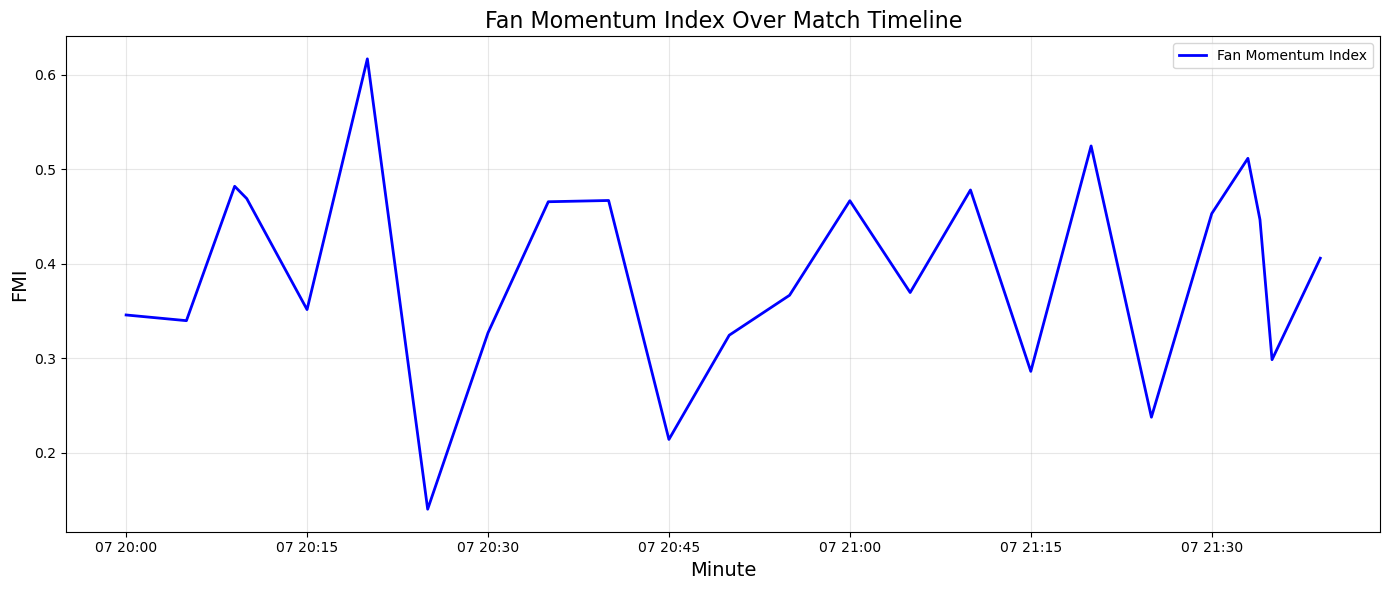

In [14]:
# Plot FMI with labels and save
plt.figure(figsize=(14, 6))
plt.plot(df["minute"], df["fmi"], color="blue", linewidth=2, label="Fan Momentum Index")

plt.title("Fan Momentum Index Over Match Timeline", fontsize=16)
plt.xlabel("Minute", fontsize=14)
plt.ylabel("FMI", fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)

# Save the figure
plt.tight_layout()
plt.savefig("fan_momentum_index.png", dpi=300)

plt.show()


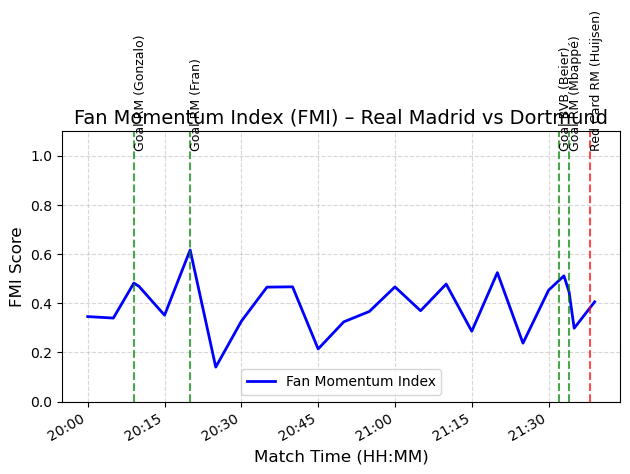

In [18]:
# Event markers
plt.plot(df["minute"], df["fmi"], color="blue", linewidth=2, label="Fan Momentum Index")

for time_str, label in events.items():
    t = pd.to_datetime(time_str)
    plt.axvline(x=t, color='red' if "Red Card" in label else 'green', linestyle='--', alpha=0.7)
    plt.text(t, 1.02, label, rotation=90, verticalalignment='bottom', fontsize=9)

# Time format and styling
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate()
plt.title("Fan Momentum Index (FMI) – Real Madrid vs Dortmund", fontsize=14)
plt.xlabel("Match Time (HH:MM)", fontsize=12)
plt.ylabel("FMI Score", fontsize=12)
plt.ylim(0, 1.1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

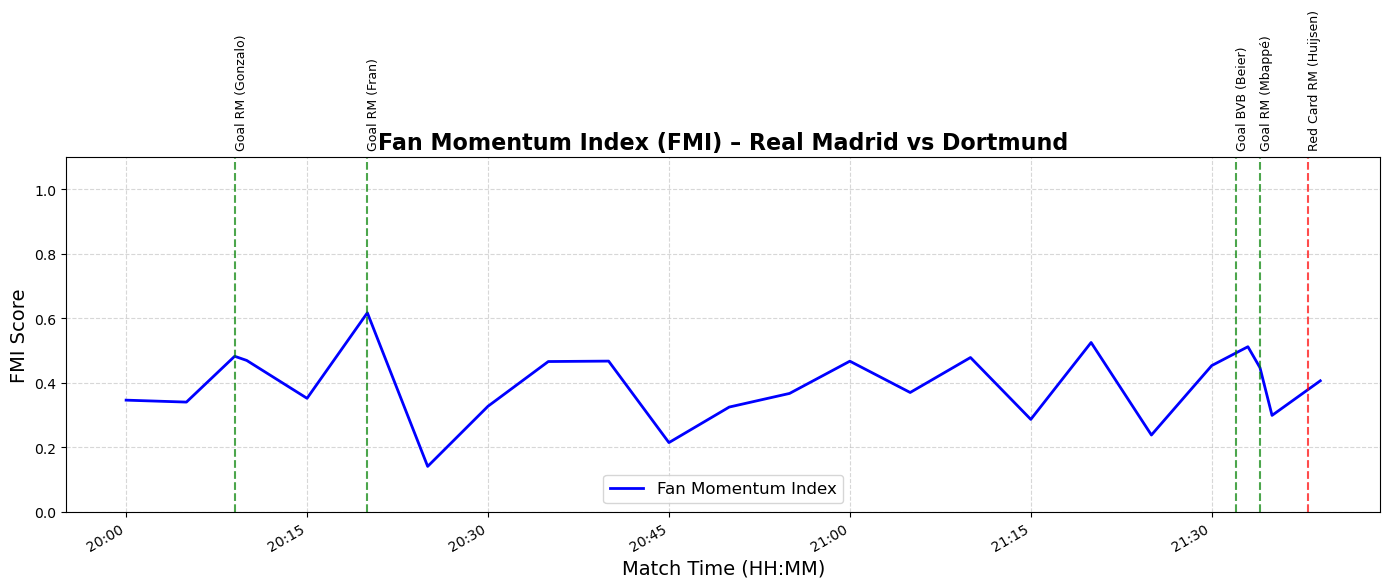

In [20]:
import matplotlib.dates as mdates

# Plot FMI with event markers
plt.figure(figsize=(14, 6))
plt.plot(df["minute"], df["fmi"], color="blue", linewidth=2, label="Fan Momentum Index")

# Add event markers
for time_str, label in events.items():
    t = pd.to_datetime(time_str)
    plt.axvline(x=t, 
                color='red' if 'Red Card' in label else 'green', 
                linestyle='--', alpha=0.7)
    plt.text(t, 1.02, label, rotation=90, va='bottom', fontsize=9, transform=plt.gca().get_xaxis_transform())

# Time format and styling
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gcf().autofmt_xdate()

# Labels and title
plt.title("Fan Momentum Index (FMI) – Real Madrid vs Dortmund", fontsize=16, fontweight='bold')
plt.xlabel("Match Time (HH:MM)", fontsize=14)
plt.ylabel("FMI Score", fontsize=14)

# Grid and legend
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.ylim(0, 1.1)

# Save the figure
plt.tight_layout()
plt.savefig("fan_momentum_index_with_events.png", dpi=300)

plt.show()


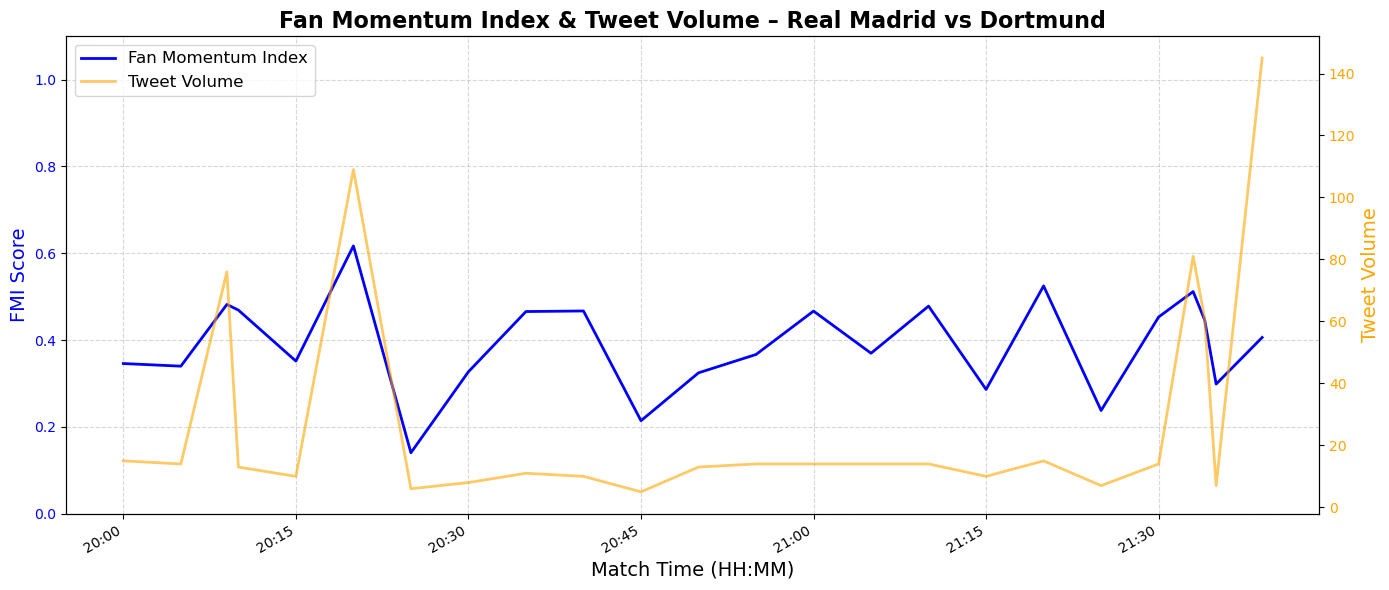

In [22]:
# Tweet Volume plot with dual y-axis styling
fig, ax1 = plt.subplots(figsize=(14, 6))

# Primary axis for FMI
ax1.plot(df["minute"], df["fmi"], color="blue", linewidth=2, label="Fan Momentum Index")
ax1.set_xlabel("Match Time (HH:MM)", fontsize=14)
ax1.set_ylabel("FMI Score", color="blue", fontsize=14)
ax1.tick_params(axis='y', labelcolor="blue")
ax1.set_ylim(0, 1.1)

# Secondary axis for Tweet Volume
ax2 = ax1.twinx()
ax2.plot(df["minute"], df["tweet_volume"], color="orange", alpha=0.6, linewidth=2, label="Tweet Volume")
ax2.set_ylabel("Tweet Volume", color="orange", fontsize=14)
ax2.tick_params(axis='y', labelcolor="orange")

# Title and formatting
plt.title("Fan Momentum Index & Tweet Volume – Real Madrid vs Dortmund", fontsize=16, fontweight='bold')
fig.autofmt_xdate()
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Grid for clarity
ax1.grid(True, linestyle='--', alpha=0.5)

# Legends from both axes
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left', fontsize=12)

# Save the figure
plt.tight_layout()
plt.savefig("fmi_tweet_volume.png", dpi=300)

plt.show()


In [40]:
# === Events → Table for final_fmi_dataset.csv ================================
import pandas as pd, numpy as np
from datetime import timedelta
from IPython.display import display 
path = r"H:\FOM- Study Material\Semester Three\Big-Data-Analysis Project\fam_momentum_index\Data\final_fmi_dataset.csv"
fmi_df = pd.read_csv(path, usecols=["minute","timestamp","fmi"])

# Parse datetimes and compute elapsed minutes from kickoff
for col in ["minute","timestamp"]:
    try:
        fmi_df[col] = pd.to_datetime(fmi_df[col], errors="coerce")
    except Exception:
        pass

time_col = "minute" if fmi_df["minute"].notna().any() else "timestamp"
fmi_df = fmi_df.dropna(subset=[time_col]).copy()
kickoff = fmi_df[time_col].iloc[0]
fmi_df["elapsed_min"] = (fmi_df[time_col] - kickoff).dt.total_seconds() / 60.0

# Helper to accept 12, "90+4", "01:30"
def as_minutes(x):
    s = str(x).strip()
    if "+" in s:
        base, add = s.split("+", 1)
        return float(base) + float(add)
    if ":" in s and len(s) <= 5:
        parts = [float(p) for p in s.split(":")]
        if len(parts) == 2:
            h, m = parts; secs = 0
        else:
            h, m, secs = parts
        return h*60 + m + secs/60.0
    return float(s)

# Real Madrid vs Dortmund — FIFA CWC QF 2025 events
events = [
    ("10",   "Goal – Real Madrid (Gonzalo García)",               "Goal",         "Real Madrid"),
    ("20",   "Goal – Real Madrid (Fran García)",                  "Goal",         "Real Madrid"),
    ("90+3", "Goal – Borussia Dortmund (Beier)",                  "Goal",         "Dortmund"),
    ("90+4", "Goal – Real Madrid (Mbappé)",                       "Goal",         "Real Madrid"),
    ("90+7", "Red Card – Real Madrid (Huijsen)",                  "Red Card",     "Real Madrid"),
    ("90+8", "Penalty Goal – Borussia Dortmund (Guirassy)",       "Penalty Goal", "Dortmund"),
]

rows = []
for t_str, label, evt_type, team in events:
    minute = as_minutes(t_str)
    nearest_idx = (fmi_df["elapsed_min"] - minute).abs().idxmin()
    nearest = fmi_df.loc[nearest_idx]
    td = timedelta(minutes=minute)
    clock = f"{int(td.seconds//3600):02d}:{int((td.seconds%3600)//60):02d}"
    rows.append({
        "Time (min)": round(minute, 2),
        "Clock (HH:MM)": clock,
        "Event": evt_type,
        "Team": team,
        "Label": label,
        "Nearest Timestamp": nearest[time_col],
        "FMI Score (nearest)": nearest["fmi"],
    })

events_df = pd.DataFrame(rows).sort_values("Time (min)").reset_index(drop=True)
display(events_df)

# Export
events_df.to_csv("fmi_match_events_rm_bvb_cwc2025.csv", index=False, encoding="utf-8")
events_df.to_excel("fmi_match_events_rm_bvb_cwc2025.xlsx", index=False)
print("Saved events to CSV & Excel.")

,Time (min),Clock (HH:MM),Event,Team,Label,Nearest Timestamp,FMI Score (nearest)
0,10.0,00:10,Goal,Real Madrid,Goal – Real Madrid (Gonzalo García),2025-07-07 20:10:00,0.468982
1,20.0,00:20,Goal,Real Madrid,Goal – Real Madrid (Fran García),2025-07-07 20:20:00,0.616900
2,93.0,01:33,Goal,Dortmund,Goal – Borussia Dortmund (Beier),2025-07-07 21:33:00,0.511604
3,94.0,01:34,Goal,Real Madrid,Goal – Real Madrid (Mbappé),2025-07-07 21:34:00,0.446559
4,97.0,01:37,Red Card,Real Madrid,Red Card – Real Madrid (Huijsen),2025-07-07 21:35:00,0.298421
5,98.0,01:38,Penalty Goal,Dortmund,Penalty Goal – Borussia Dortmund (Guirassy),2025-07-07 21:39:00,0.405838


Saved events to CSV & Excel.


In [26]:
import numpy as np
import random
import time
import IPython.display as display
from IPython.display import clear_output, Markdown

def get_fan_instruction(fmi, delta_fmi, event=None):
    if event == "red_card":
        return "🟥 Red Card! Show support — chant the player's name! 🔊"
    elif event == "goal_scored":
        return "⚽ GOAL! Wave your scarves and roar! 🥳"
    elif fmi >= 0.8 and delta_fmi >= 0:
        return "🟢 You're unstoppable! Let them hear you! 🔊"
    elif fmi >= 0.6 and delta_fmi < 0:
        return "🟡 Don’t slow down now! Clap in sync! 👏"
    elif 0.4 <= fmi < 0.6:
        return "🟡 Let’s build it up — whistle together! 🎶"
    elif 0.3 <= fmi < 0.4 and delta_fmi < 0:
        return "🟠 Wake up the players! STOMP NOW! 👣"
    elif fmi < 0.3 and delta_fmi < 0:
        return "🔴 DEFCON 1! Whistle, scream, chant — PUSH! 🚨"
    elif fmi < 0.3 and delta_fmi >= 0:
        return "🔴 YES! Don't stop now — keep the energy high! 🚀"
    else:
        return "⚠️ Keep the energy flowing! Every voice counts! 💪"

def simulate_fan_display():
    prev_fmi = random.uniform(0.3, 0.7)
    for _ in range(15):
        fmi = np.clip(prev_fmi + random.uniform(-0.1, 0.1), 0, 1)
        delta_fmi = fmi - prev_fmi
        event = random.choice(["goal_scored", "red_card", None]) if random.random() < 0.1 else None

        instruction = get_fan_instruction(fmi, delta_fmi, event)

        clear_output(wait=True)
        display.display(Markdown(f"""
### **Live Fan Orchestration System**

**FMI Score**: `{fmi:.2f}`  
**Trend**: `{"↗ Rising" if delta_fmi > 0 else "↘ Falling" if delta_fmi < 0 else "→ Stable"}`  
**Event**: `{event if event else "-"}`
___

### **Fan Instruction:**
# {instruction}
        """))
        prev_fmi = fmi
        time.sleep(2)

simulate_fan_display()



### **Live Fan Orchestration System**

**FMI Score**: `0.34`  
**Trend**: `↗ Rising`  
**Event**: `-`
___

### **Fan Instruction:**
# ⚠️ Keep the energy flowing! Every voice counts! 💪
        